<a href="https://colab.research.google.com/github/adi-doke/CodSoft-Internship-Projects/blob/main/Malaysian_data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Malaysian Web Platform User Engagement Survey
### Complete Data Analysis & Feature Engineering

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from collections import Counter

import warnings
warnings.filterwarnings('ignore')


## 2. Load the dataset

The dataset is a survey-based dataset collected from Malaysian internet users about their experience with Malaysian web platforms — things like government portals, e-commerce sites, news portals, social media, and blogs.

It captured information across five broad areas:

1. Demographics — age, gender, occupation

2. Internet behavior — how often they use the internet, which device they primarily use, and their main reason for going online

3. Engagement patterns — how frequently they interacted with specific activities like online shopping, reading articles, watching videos, participating in discussions, and social media

4. Experience ratings — satisfaction, likelihood to recommend, accessibility for people with disabilities, and how successful they were at finding what they needed — all rated on a 1 to 5 scale

5. Open-ended feedback — what improvements they'd suggest and what additional features they'd like to see

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Malaysian_Survey_data.xlsx to Malaysian_Survey_data.xlsx


In [ ]:
df = pd.read_excel('Malaysian_Survey_data.xlsx')
df

,"By clicking 'I agree' below, you are indicating that you have read and understood this consent form and agree to participate in this research study. If you are under 18 years old, you confirm that you have obtained parental or guardian consent to participate.",What is your age?,What is your gender?,What is your occupation?,How often do you use the internet?,Which device do you primarily use to access the internet?,What is your main reason for using the internet?,What types of Malaysian web platforms do you frequently visit?,How often do you interact with online shopping on websites?,How often do you interact with reading articles on websites?,How often do you interact with watching videos on websites?,How often do you interact with participating in online discussions on websites?,How often do you interact with social media integration on websites?,"How satisfied are you with the overall user experience of Malaysian web platforms? (Rate on a scale of 1-5, where 1 is 'Very Dissatisfied' and 5 is 'Very Satisfied')","How likely are you to recommend Malaysian web platforms to others? (Rate on a scale of 1-5, where 1 is 'Very Unlikely' and 5 is 'Very Likely')","How accessible do you find Malaysian web platforms for people with disabilities? (Rate on a scale of 1-5, where 1 is 'Not Accessible at All' and 5 is 'Very Accessible')","How successful are you at finding what you need on Malaysian web platforms? (Rate on a scale of 1-5, where 1 is 'Never Successful' and 5 is 'Always Successful')",What improvements would you suggest for Malaysian web platforms to enhance your experience?,Are there any additional features you would like to see implemented on Malaysian web platforms?
0,Agree,25 - 34,Male,Employed,Daily,Desktop,Work,E-commerce,2.0,3.0,2,4,4,1.0,4.0,3,5,NaN,NaN
1,Agree,45 - 54,Female,Employed,Several times a month,Laptop,Entertainment,Educational sites,2.0,4.0,3,2,4,4.0,5.0,2,4,Mobile Optimization,NaN
2,Agree,55 - 64,Female,Retired,Several times a month,Laptop,Social Media,Forums,2.0,4.0,3,3,3,1.0,3.0,3,1,Enhanced Data Protection,Sustainability Features
3,Agree,Under 18,Female,Employed,Daily,Desktop,Entertainment,Social media,5.0,2.0,4,4,2,1.0,3.0,1,5,NaN,NaN
4,Agree,55 - 64,Female,Employed,Several times a month,Tablet,Shopping,E-commerce,4.0,3.0,4,5,3,1.0,2.0,5,4,NaN,Sustainability Features
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025,Agree,45 - 54,Female,Retired,Several times a week,Smartphone,Shopping,Educational sites,4.0,2.0,4,4,3,3.0,5.0,3,2,Enhanced Data Protection,Advanced Localization Features
2026,Agree,45 - 54,Female,Student,Rarely,Laptop,News and Information,E-commerce,3.0,1.0,4,2,4,3.0,3.0,4,4,Mobile Optimization,NaN
2027,Agree,25 - 34,Male,Self-employed,Several times a month,Desktop,Shopping,Government services,3.0,3.0,4,3,4,3.0,3.0,4,2,Enhanced Data Protection,Unified Payment Gateways
2028,Agree,Under 18,Female,Self-employed,Once a week,Tablet,News and Information,Educational sites,5.0,4.0,3,5,4,3.0,4.0,3,2,NaN,NaN


## 3. Initial df Inspection

In [ ]:
df.shape

(2030, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 19 columns):
 #   Column                                                                                                                                                                                                                                                               Non-Null Count  Dtype  
---  ------                                                                                                                                                                                                                                                               --------------  -----  
 0   By clicking 'I agree' below, you are indicating that you have read and understood this consent form and agree to participate in this research study. If you are under 18 years old, you confirm that you have obtained parental or guardian consent to participate.  2030 non-null   object 
 1   What is your age? 

In [ ]:
df.describe()

,How often do you interact with online shopping on websites?,How often do you interact with reading articles on websites?,How often do you interact with watching videos on websites?,How often do you interact with participating in online discussions on websites?,How often do you interact with social media integration on websites?,"How satisfied are you with the overall user experience of Malaysian web platforms? (Rate on a scale of 1-5, where 1 is 'Very Dissatisfied' and 5 is 'Very Satisfied')","How likely are you to recommend Malaysian web platforms to others? (Rate on a scale of 1-5, where 1 is 'Very Unlikely' and 5 is 'Very Likely')","How accessible do you find Malaysian web platforms for people with disabilities? (Rate on a scale of 1-5, where 1 is 'Not Accessible at All' and 5 is 'Very Accessible')","How successful are you at finding what you need on Malaysian web platforms? (Rate on a scale of 1-5, where 1 is 'Never Successful' and 5 is 'Always Successful')"
count,2000.000000,1981.000000,2030.000000,2030.000000,2030.000000,2010.000000,1994.000000,2030.000000,2030.000000
mean,3.139500,3.253912,3.334483,2.999015,3.179803,3.172637,3.222668,3.142857,3.262069
std,1.272733,1.202540,1.192610,1.293727,1.244678,1.173605,1.167191,3.237332,1.218508
min,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,7.000000,6.000000,7.000000,7.000000,6.000000,6.000000,7.000000,99.000000,7.000000


In [ ]:
df.describe(include='object')

,"By clicking 'I agree' below, you are indicating that you have read and understood this consent form and agree to participate in this research study. If you are under 18 years old, you confirm that you have obtained parental or guardian consent to participate.",What is your age?,What is your gender?,What is your occupation?,How often do you use the internet?,Which device do you primarily use to access the internet?,What is your main reason for using the internet?,What types of Malaysian web platforms do you frequently visit?,What improvements would you suggest for Malaysian web platforms to enhance your experience?,Are there any additional features you would like to see implemented on Malaysian web platforms?
count,2030,2003,1978,1993,1983,1989,2003,1992,1418,1481
unique,1,15,5,10,12,4,6,7,7,6
top,Agree,25 - 34,Female,Employed,Daily,Laptop,Entertainment,Social media,Better Search Functionality,Advanced Localization Features
freq,2030,447,1075,561,512,688,361,305,231,258


In [ ]:
# Missing values
df.isnull().sum()

,0
"By clicking 'I agree' below, you are indicating that you have read and understood this consent form and agree to participate in this research study. If you are under 18 years old, you confirm that you have obtained parental or guardian consent to participate.",0
What is your age?,27
What is your gender?,52
What is your occupation?,37
How often do you use the internet?,47
Which device do you primarily use to access the internet?,41
What is your main reason for using the internet?,27
What types of Malaysian web platforms do you frequently visit?,38
How often do you interact with online shopping on websites?,30
How often do you interact with reading articles on websites?,49


## 4. Drop Irrelevant Columns
The first column is a consent/agreement column — all values are 'Agree' and it carries no analytical information.

In [ ]:
df.columns

Index(['By clicking 'I agree' below, you are indicating that you have read and understood this consent form and agree to participate in this research study. If you are under 18 years old, you confirm that you have obtained parental or guardian consent to participate.',
       'What is your age?', 'What is your gender?', 'What is your occupation?',
       'How often do you use the internet?',
       'Which device do you primarily use to access the internet?',
       'What is your main reason for using the internet?',
       'What types of Malaysian web platforms do you frequently visit?',
       'How often do you interact with online shopping on websites?',
       'How often do you interact with reading articles on websites?',
       'How often do you interact with watching videos on websites?',
       'How often do you interact with participating in online discussions on websites?',
       'How often do you interact with social media integration on websites?',
       'How satisfied are

In [ ]:
# Droping the first columns which is irrelavant
df = df.drop(df.columns[0], axis=1)

In [ ]:
df.shape[1]

18

In [ ]:
df

,What is your age?,What is your gender?,What is your occupation?,How often do you use the internet?,Which device do you primarily use to access the internet?,What is your main reason for using the internet?,What types of Malaysian web platforms do you frequently visit?,How often do you interact with online shopping on websites?,How often do you interact with reading articles on websites?,How often do you interact with watching videos on websites?,How often do you interact with participating in online discussions on websites?,How often do you interact with social media integration on websites?,"How satisfied are you with the overall user experience of Malaysian web platforms? (Rate on a scale of 1-5, where 1 is 'Very Dissatisfied' and 5 is 'Very Satisfied')","How likely are you to recommend Malaysian web platforms to others? (Rate on a scale of 1-5, where 1 is 'Very Unlikely' and 5 is 'Very Likely')","How accessible do you find Malaysian web platforms for people with disabilities? (Rate on a scale of 1-5, where 1 is 'Not Accessible at All' and 5 is 'Very Accessible')","How successful are you at finding what you need on Malaysian web platforms? (Rate on a scale of 1-5, where 1 is 'Never Successful' and 5 is 'Always Successful')",What improvements would you suggest for Malaysian web platforms to enhance your experience?,Are there any additional features you would like to see implemented on Malaysian web platforms?
0,25 - 34,Male,Employed,Daily,Desktop,Work,E-commerce,2.0,3.0,2,4,4,1.0,4.0,3,5,NaN,NaN
1,45 - 54,Female,Employed,Several times a month,Laptop,Entertainment,Educational sites,2.0,4.0,3,2,4,4.0,5.0,2,4,Mobile Optimization,NaN
2,55 - 64,Female,Retired,Several times a month,Laptop,Social Media,Forums,2.0,4.0,3,3,3,1.0,3.0,3,1,Enhanced Data Protection,Sustainability Features
3,Under 18,Female,Employed,Daily,Desktop,Entertainment,Social media,5.0,2.0,4,4,2,1.0,3.0,1,5,NaN,NaN
4,55 - 64,Female,Employed,Several times a month,Tablet,Shopping,E-commerce,4.0,3.0,4,5,3,1.0,2.0,5,4,NaN,Sustainability Features
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025,45 - 54,Female,Retired,Several times a week,Smartphone,Shopping,Educational sites,4.0,2.0,4,4,3,3.0,5.0,3,2,Enhanced Data Protection,Advanced Localization Features
2026,45 - 54,Female,Student,Rarely,Laptop,News and Information,E-commerce,3.0,1.0,4,2,4,3.0,3.0,4,4,Mobile Optimization,NaN
2027,25 - 34,Male,Self-employed,Several times a month,Desktop,Shopping,Government services,3.0,3.0,4,3,4,3.0,3.0,4,2,Enhanced Data Protection,Unified Payment Gateways
2028,Under 18,Female,Self-employed,Once a week,Tablet,News and Information,Educational sites,5.0,4.0,3,5,4,3.0,4.0,3,2,NaN,NaN


## 5. Rename Columns for Readability

In [ ]:
df.rename(columns={
    'What is your age?'                                                                                                                                : 'Age',
    'What is your gender?'                                                                                                                             : 'Gender',
    'What is your occupation?'                                                                                                                         : 'Occupation',
    'How often do you use the internet?'                                                                                                               : 'Internet_Usage',
    'Which device do you primarily use to access the internet?'                                                                                        : 'Primary_Device',
    'What is your main reason for using the internet?'                                                                                                 : 'Main_Use',
    'What types of Malaysian web platforms do you frequently visit?'                                                                                   : 'Web_Types',
    'How often do you interact with online shopping on websites?'                                                                                      : 'Shopping_Frequency',
    'How often do you interact with reading articles on websites?'                                                                                     : 'Reading_Frequency',
    'How often do you interact with watching videos on websites?'                                                                                      : 'Video_Frequency',
    'How often do you interact with participating in online discussions on websites?'                                                                   : 'Discussion_Frequency',
    'How often do you interact with social media integration on websites?'                                                                             : 'Social_Media_Integration',
    "How satisfied are you with the overall user experience of Malaysian web platforms? (Rate on a scale of 1-5, where 1 is 'Very Dissatisfied' and 5 is 'Very Satisfied')" : 'Satisfaction',
    "How likely are you to recommend Malaysian web platforms to others? (Rate on a scale of 1-5, where 1 is 'Very Unlikely' and 5 is 'Very Likely')"                         : 'Recommendation',
    "How accessible do you find Malaysian web platforms for people with disabilities? (Rate on a scale of 1-5, where 1 is 'Not Accessible at All' and 5 is 'Very Accessible')" : 'Accessibility',
    "How successful are you at finding what you need on Malaysian web platforms? (Rate on a scale of 1-5, where 1 is 'Never Successful' and 5 is 'Always Successful')"         : 'Success',
    'What improvements would you suggest for Malaysian web platforms to enhance your experience?'         : 'Improvement_Suggestions',
    'Are there any additional features you would like to see implemented on Malaysian web platforms?'     : 'Additional_Features',
}, inplace=True)
print("Columns renamed:")
print(df.columns.tolist())

Columns renamed:
['Age', 'Gender', 'Occupation', 'Internet_Usage', 'Primary_Device', 'Main_Use', 'Web_Types', 'Shopping_Frequency', 'Reading_Frequency', 'Video_Frequency', 'Discussion_Frequency', 'Social_Media_Integration', 'Satisfaction', 'Recommendation', 'Accessibility', 'Success', 'Improvement_Suggestions', 'Additional_Features']


## 6. Standardise & Clean Categorical Columns
The 2000-row df contains various inconsistent entries (different casing, spacing, abbreviations).  
We normalise each column to a canonical set of values.

### 6.1 Age — normalise to uniform ranges

In [ ]:
print("Raw Age value_counts:")
df['Age'].value_counts().to_string()

Raw Age value_counts:


'Age\n25 - 34          447\n45 - 54          319\n35 - 44          288\n18 - 24          267\n55 - 64          264\nUnder 18         239\n65 and above     140\n18-24              8\n55 - 64 years      7\nAbove 65           5\n18 to 24           5\nunder 18           5\n65+                4\n25-34              3\n25 to 34           2'

In [ ]:
def standardise_age(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    if val in ('under 18', 'under18', '0-18', '<18', '< 18'):
        return '0-18'
    if val in ('18 - 24', '18-24', '18 to 24', '18–24'):
        return '18-24'
    if val in ('25 - 34', '25-34', '25 to 34', '25–34'):
        return '25-34'
    if val in ('35 - 44', '35-44', '35 to 44', '35–44'):
        return '35-44'
    if val in ('45 - 54', '45-54', '45 to 54', '45–54'):
        return '45-54'
    if val in ('55 - 64', '55-64', '55 to 64', '55–64', '55 - 64 years'):
        return '55-64'
    if val in ('65 and above', '65+', 'above 65', '65-100', '65 and over', '65 & above'):
        return '65+'
    return np.nan   # unmapped → treated as missing

df['Age'] = df['Age'].apply(standardise_age)
print("Cleaned Age distribution:")
print(df['Age'].value_counts().sort_index())

Cleaned Age distribution:
Age
0-18     244
18-24    280
25-34    452
35-44    288
45-54    319
55-64    271
65+      149
Name: count, dtype: int64


### 6.2 Gender — normalise casing and whitespace

In [ ]:
print("Raw Gender value_counts:")
print(df['Gender'].value_counts().to_string())

Raw Gender value_counts:
Gender
Female       1075
Male          855
  Female       19
female         15
  Male         14


In [ ]:
df['Gender'] = df['Gender'].replace({
    'male' : 'Male',
    'female': 'Female',
})

In [ ]:
print(df['Gender'].value_counts().to_string())

Gender
Female       1090
Male          855
  Female       19
  Male         14


In [ ]:
df['Gender'] = (df['Gender']
                .str.lower() #converts to lowercase
                .str.strip() #Removes extra spaces.
                .str.title()) # Capitalize first letter

In [ ]:
print(df['Gender'].value_counts().to_string())

Gender
Female    1109
Male       869


### 6.3 Occupation — normalise casing

In [ ]:
print("Raw Occupation value_counts:")
print(df['Occupation'].value_counts().to_string())

Raw Occupation value_counts:
Occupation
Employed         561
Student          425
Self-employed    367
Unemployed       295
Retired          294
employed          14
self-employed     12
unemployed        12
retired            7
student            6


In [ ]:
df['Occupation'] = df['Occupation'].str.strip().str.lower().str.title()


df['Occupation'].value_counts()

,count
Occupation,
Employed,575
Student,431
Self-Employed,379
Unemployed,307
Retired,301


### 6.4 Internet Usage — normalise casing

In [ ]:
print("Raw Internet_Usage value_counts:")
print(df['Internet_Usage'].value_counts().to_string())

Raw Internet_Usage value_counts:
Internet_Usage
Daily                    512
Several times a month    398
Several times a week     358
Once a week              278
Once a month             236
Rarely                   172
once a week                8
Several times / month      7
daily                      5
DAILY                      4
Once a Day                 3
Rarely ever                2


In [ ]:
df['Internet_Usage'] = df['Internet_Usage'].str.lower().str.strip()


print(df['Internet_Usage'].value_counts().to_string())

Internet_Usage
daily                    521
several times a month    398
several times a week     358
once a week              286
once a month             236
rarely                   172
several times / month      7
once a day                 3
rarely ever                2


In [ ]:
def standardise_usage(val):
    if pd.isna(val):
        return np.nan
    v = str(val).strip().lower()
    if v in ('daily', 'once a day', 'every day'):
        return 'Daily'
    if 'several' in v and 'week' in v:
        return 'Several times a week'
    if 'several' in v and 'month' in v:
        return 'Several times a month'
    if v in ('once a week', 'weekly', '1x week'):
        return 'Once a week'
    if v in ('once a month', 'monthly', '1x month'):
        return 'Once a month'
    if 'rare' in v:
        return 'Rarely'
    return np.nan

df['Internet_Usage'] = df['Internet_Usage'].apply(standardise_usage)
print("Cleaned Internet_Usage distribution:")
print(df['Internet_Usage'].value_counts())

Cleaned Internet_Usage distribution:
Internet_Usage
Daily                    524
Several times a month    405
Several times a week     358
Once a week              286
Once a month             236
Rarely                   174
Name: count, dtype: int64


In [ ]:
df['Video_Frequency'].value_counts()

,count
Video_Frequency,
4,599
3,528
5,377
2,374
1,150
-1,1
7,1


### 6.5 Frequency columns — clamp to valid 1-5 range

In [ ]:
freq_cols = ['Shopping_Frequency', 'Reading_Frequency', 'Video_Frequency',
             'Discussion_Frequency', 'Social_Media_Integration']

for cols in freq_cols:
  print(df[cols].value_counts())
  print("****************************")

#There are some inconsistent values outside from 1-5 scale.


Shopping_Frequency
4.0    538
3.0    452
2.0    441
5.0    326
1.0    240
6.0      2
7.0      1
Name: count, dtype: int64
****************************
Reading_Frequency
4.0    602
3.0    537
2.0    328
5.0    313
1.0    200
6.0      1
Name: count, dtype: int64
****************************
Video_Frequency
 4    599
 3    528
 5    377
 2    374
 1    150
-1      1
 7      1
Name: count, dtype: int64
****************************
Discussion_Frequency
 3    506
 4    471
 2    442
 1    310
 5    296
 0      2
-1      1
 7      1
 6      1
Name: count, dtype: int64
****************************
Social_Media_Integration
 4    559
 3    516
 2    399
 5    329
 1    223
 0      2
 6      1
-1      1
Name: count, dtype: int64
****************************


In [ ]:
freq_cols = ['Shopping_Frequency', 'Reading_Frequency', 'Video_Frequency',
             'Discussion_Frequency', 'Social_Media_Integration']

for col in freq_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce') #This line converts strings if any (e.g., "3", "1 (Never)", "five" into a proper number. Anything that can't be converted (like text garbage) becomes NaN instead of throwing an error — that's what errors='coerce' does.

    df[col] = df[col].where(df[col].between(1, 5), np.nan) #Even after converting to numeric, the dataset had invalid entries like -1, 0, 6, 7 which are clearly data-entry mistakes on a 1–5 scale. This line says: Keep the value if it's between 1 and 5. Replace with NaN if it's anything else

print("Frequency column value counts after cleaning:")
for col in freq_cols:
    print(df[cols].value_counts().sort_index())

Frequency column value counts after cleaning:
Social_Media_Integration
1.0    223
2.0    399
3.0    516
4.0    559
5.0    329
Name: count, dtype: int64
Social_Media_Integration
1.0    223
2.0    399
3.0    516
4.0    559
5.0    329
Name: count, dtype: int64
Social_Media_Integration
1.0    223
2.0    399
3.0    516
4.0    559
5.0    329
Name: count, dtype: int64
Social_Media_Integration
1.0    223
2.0    399
3.0    516
4.0    559
5.0    329
Name: count, dtype: int64
Social_Media_Integration
1.0    223
2.0    399
3.0    516
4.0    559
5.0    329
Name: count, dtype: int64


### 6.6 Rating columns — clamp to valid 1-5 range

In [ ]:
rating_cols = ['Satisfaction', 'Recommendation', 'Accessibility', 'Success']

for cols in rating_cols:
  print(df[cols].value_counts().sort_index())
  print("************************************")

Satisfaction
-1.0      1
 1.0    202
 2.0    354
 3.0    612
 4.0    575
 5.0    264
 6.0      2
Name: count, dtype: int64
************************************
Recommendation
1.0    193
2.0    319
3.0    614
4.0    591
5.0    275
7.0      2
Name: count, dtype: int64
************************************
Accessibility
1     266
2     360
3     638
4     541
5     221
6       1
7       1
99      2
Name: count, dtype: int64
************************************
Success
1    205
2    339
3    558
4    577
5    350
7      1
Name: count, dtype: int64
************************************


In [ ]:
rating_cols = ['Satisfaction', 'Recommendation', 'Accessibility', 'Success']

for cols in rating_cols:
  df[cols] = pd.to_numeric(df[cols], errors = 'coerce')
  df[cols] = df[cols].where(df[cols].between(1,5), np.nan)

df[rating_cols].describe()

#Minimum is 1 and Max is 5

,Satisfaction,Recommendation,Accessibility,Success
count,2007.000000,1992.000000,2026.000000,2029.000000
mean,3.171898,3.218876,3.044916,3.260227
std,1.167373,1.161618,1.185283,1.215977
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000
50%,3.000000,3.000000,3.000000,3.000000
75%,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000


## 7. Missing Value Analysis & Imputation

In [ ]:
# Missing values per column
df.isnull().sum()

,0
Age,27
Gender,52
Occupation,37
Internet_Usage,47
Primary_Device,41
Main_Use,27
Web_Types,38
Shopping_Frequency,33
Reading_Frequency,50
Video_Frequency,2


In [ ]:
# Missing values percentage per column

missing_percentage = (df.isnull().sum() / len(df))*100

missing_percentage.sort_values(ascending = False)

,0
Improvement_Suggestions,30.147783
Additional_Features,27.044335
Gender,2.561576
Reading_Frequency,2.463054
Internet_Usage,2.315271
Primary_Device,2.019704
Web_Types,1.871921
Recommendation,1.871921
Occupation,1.822660
Shopping_Frequency,1.625616


In [ ]:
# Missing values with percentage per column

missing_values = df.isnull().sum()

missing_df = pd.DataFrame ({
    'missing_count' : missing_values,
    'missing_percentage' : missing_percentage
})

missing_df.sort_values('missing_percentage', ascending=False)

,missing_count,missing_percentage
Improvement_Suggestions,612,30.147783
Additional_Features,549,27.044335
Gender,52,2.561576
Reading_Frequency,50,2.463054
Internet_Usage,47,2.315271
Primary_Device,41,2.019704
Web_Types,38,1.871921
Recommendation,38,1.871921
Occupation,37,1.822660
Shopping_Frequency,33,1.625616


In [ ]:
missing_df = missing_df.reset_index().sort_values('missing_percentage',ascending=False) #reset_index() moves the index (feature names) into an actual column.

missing_df


#sort_values(column_name, ascending=False) -> sort_values() needs a column name — otherwise pandas doesn't know which column to sort on, and throws an error.

,index,missing_count,missing_percentage
16,Improvement_Suggestions,612,30.147783
17,Additional_Features,549,27.044335
1,Gender,52,2.561576
8,Reading_Frequency,50,2.463054
3,Internet_Usage,47,2.315271
4,Primary_Device,41,2.019704
6,Web_Types,38,1.871921
13,Recommendation,38,1.871921
2,Occupation,37,1.822660
7,Shopping_Frequency,33,1.625616


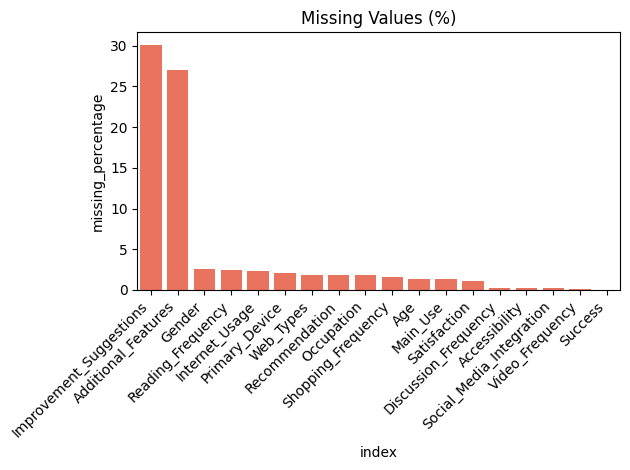

In [ ]:
# Missing values visualization with Barplot

sns.barplot(data=missing_df, x='index', y= 'missing_percentage', color='tomato')
plt.title('Missing Values (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df.dtypes

,0
Age,object
Gender,object
Occupation,object
Internet_Usage,object
Primary_Device,object
Main_Use,object
Web_Types,object
Shopping_Frequency,float64
Reading_Frequency,float64
Video_Frequency,float64


Missing Values Imputation

In [ ]:
# Numeric missing values Imputation

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numeric_cols)
print("****************************")

for col in numeric_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    df[col] = df[col].round(0).astype(int)

print(df[numeric_cols].isnull().sum())

['Shopping_Frequency', 'Reading_Frequency', 'Video_Frequency', 'Discussion_Frequency', 'Social_Media_Integration', 'Satisfaction', 'Recommendation', 'Accessibility', 'Success']
****************************
Shopping_Frequency          0
Reading_Frequency           0
Video_Frequency             0
Discussion_Frequency        0
Social_Media_Integration    0
Satisfaction                0
Recommendation              0
Accessibility               0
Success                     0
dtype: int64


In [ ]:
# Categorical Missing values imputation

categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)
print("***********************")


for col in categorical_cols:
  mode_val = df[col].mode()[0]
  df[col].fillna(mode_val, inplace=True)

print(df[categorical_cols].isnull().sum())

['Age', 'Gender', 'Occupation', 'Internet_Usage', 'Primary_Device', 'Main_Use', 'Web_Types', 'Improvement_Suggestions', 'Additional_Features']
***********************
Age                        0
Gender                     0
Occupation                 0
Internet_Usage             0
Primary_Device             0
Main_Use                   0
Web_Types                  0
Improvement_Suggestions    0
Additional_Features        0
dtype: int64


In [ ]:
# ── Open-ended text: fill with 'Not Specified' ───────────────────────────────
df['Improvement_Suggestions'].fillna('Not Specified', inplace=True)
df['Additional_Features'].fillna('Not Specified', inplace=True)

print(df.isnull().sum())

Age                         0
Gender                      0
Occupation                  0
Internet_Usage              0
Primary_Device              0
Main_Use                    0
Web_Types                   0
Shopping_Frequency          0
Reading_Frequency           0
Video_Frequency             0
Discussion_Frequency        0
Social_Media_Integration    0
Satisfaction                0
Recommendation              0
Accessibility               0
Success                     0
Improvement_Suggestions     0
Additional_Features         0
dtype: int64


## 8. Duplicate Row Detection & Removal

In [ ]:
#Check number of duplicate rows
df.duplicated().sum()

#or

# duplicate = df.duplicated().sum()
# print(f"Duplicate rows : {duplicate}")


np.int64(24)

In [ ]:
# Drop duplicate values

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

## 9. Final Data Types & Schema

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2006 entries, 0 to 2005
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       2006 non-null   object
 1   Gender                    2006 non-null   object
 2   Occupation                2006 non-null   object
 3   Internet_Usage            2006 non-null   object
 4   Primary_Device            2006 non-null   object
 5   Main_Use                  2006 non-null   object
 6   Web_Types                 2006 non-null   object
 7   Shopping_Frequency        2006 non-null   int64 
 8   Reading_Frequency         2006 non-null   int64 
 9   Video_Frequency           2006 non-null   int64 
 10  Discussion_Frequency      2006 non-null   int64 
 11  Social_Media_Integration  2006 non-null   int64 
 12  Satisfaction              2006 non-null   int64 
 13  Recommendation            2006 non-null   int64 
 14  Accessibility           

## 10. Exploratory Data Analysis (EDA)


### Univariate Analysis

#### 10.1 Responses by Age Group

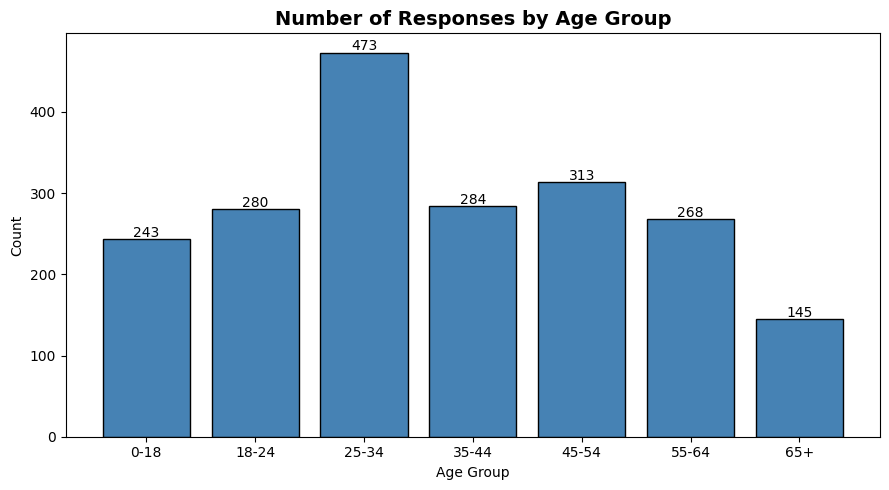

In [ ]:
age_order  = ['0-18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
age_counts = df['Age'].value_counts().reindex(age_order)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(age_counts.index, age_counts.values, color='steelblue', edgecolor='black')
ax.set_title('Number of Responses by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group'); ax.set_ylabel('Count')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(int(bar.get_height())), ha='center', fontsize=10)
plt.tight_layout(); plt.show()

#### 10.2 Gender Distribution

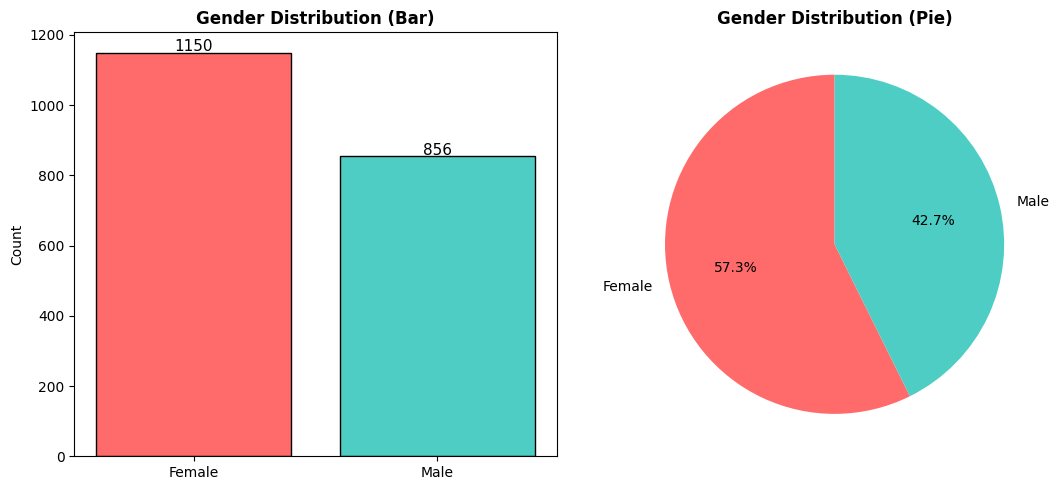

In [ ]:
gender_counts = df['Gender'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
colors = ['#FF6B6B', '#4ECDC4', '#FFD93D'][:len(gender_counts)]

axes[0].bar(gender_counts.index, gender_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Gender Distribution (Bar)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=11)

axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Gender Distribution (Pie)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

#### 10.3 Occupation Distribution

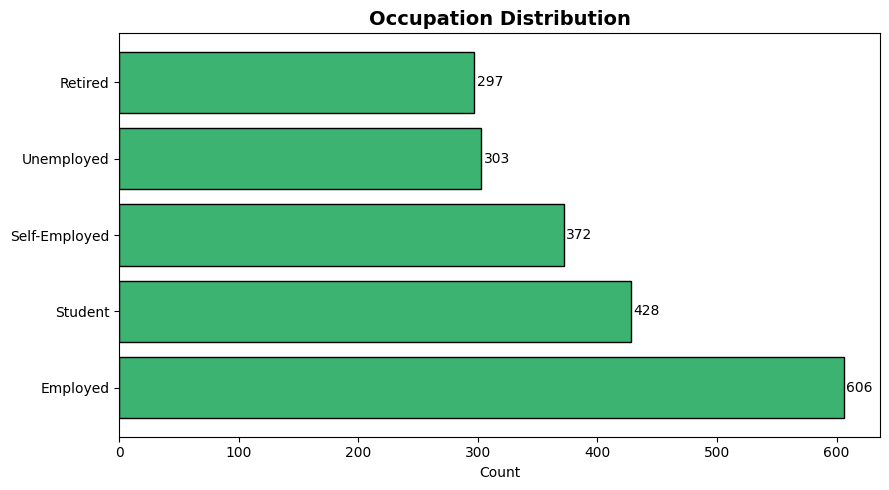

In [ ]:
occ_counts = df['Occupation'].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(occ_counts.index, occ_counts.values, color='mediumseagreen', edgecolor='black')
ax.set_title('Occupation Distribution', fontsize=14, fontweight='bold'); ax.set_xlabel('Count')
for bar in bars:
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=10)
plt.tight_layout(); plt.show()

#### 10.4 Internet Usage Frequency

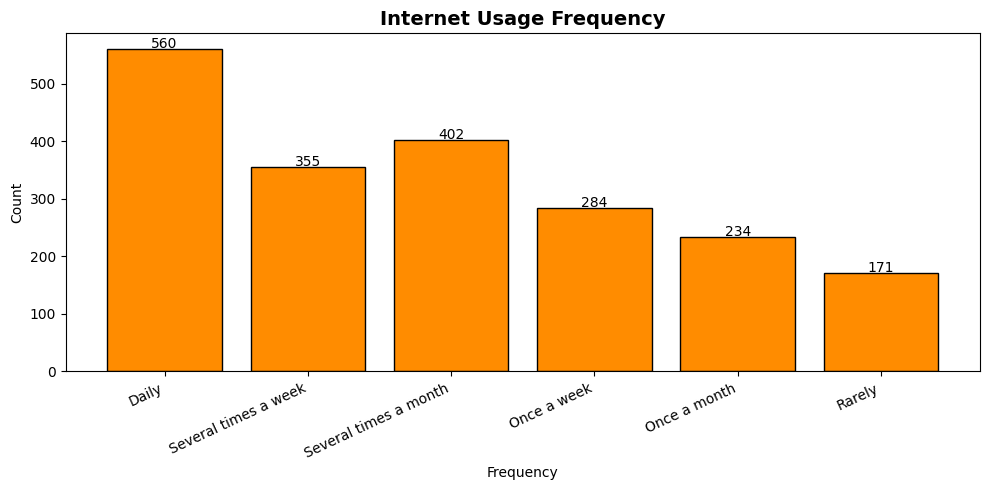

In [ ]:
usage_order  = ['Daily', 'Several times a week', 'Several times a month',
                'Once a week', 'Once a month', 'Rarely']
usage_counts = df['Internet_Usage'].value_counts().reindex(usage_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(usage_counts.index, usage_counts.values, color='darkorange', edgecolor='black')
ax.set_title('Internet Usage Frequency', fontsize=14, fontweight='bold')
ax.set_xlabel('Frequency'); ax.set_ylabel('Count')
plt.xticks(rotation=25, ha='right')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(bar.get_height())), ha='center', fontsize=10)
plt.tight_layout(); plt.show()

#### 10.5 Primary Device Used

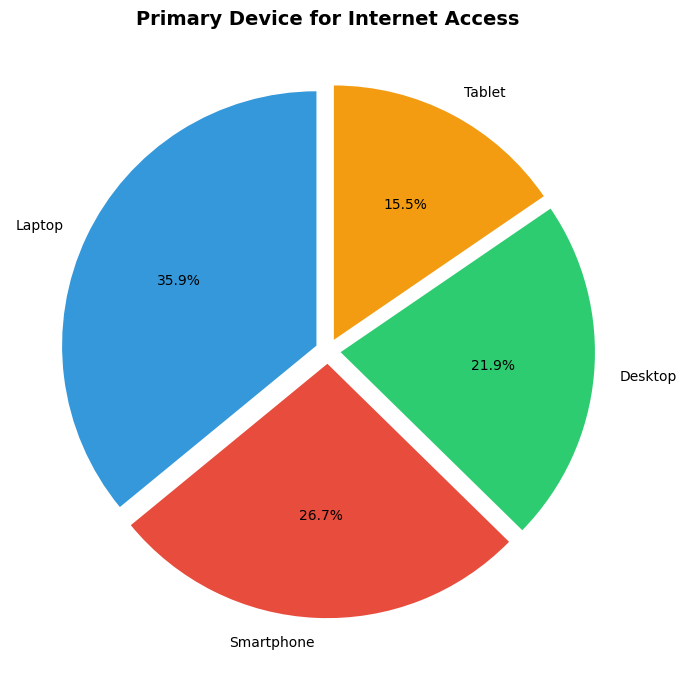

In [ ]:
device_counts = df['Primary_Device'].value_counts()
colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(device_counts.values, labels=device_counts.index, autopct='%1.1f%%',
       colors=colors[:len(device_counts)], startangle=90, explode=[0.05]*len(device_counts))
ax.set_title('Primary Device for Internet Access', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

#### 10.6 Main Reason for Using the Internet

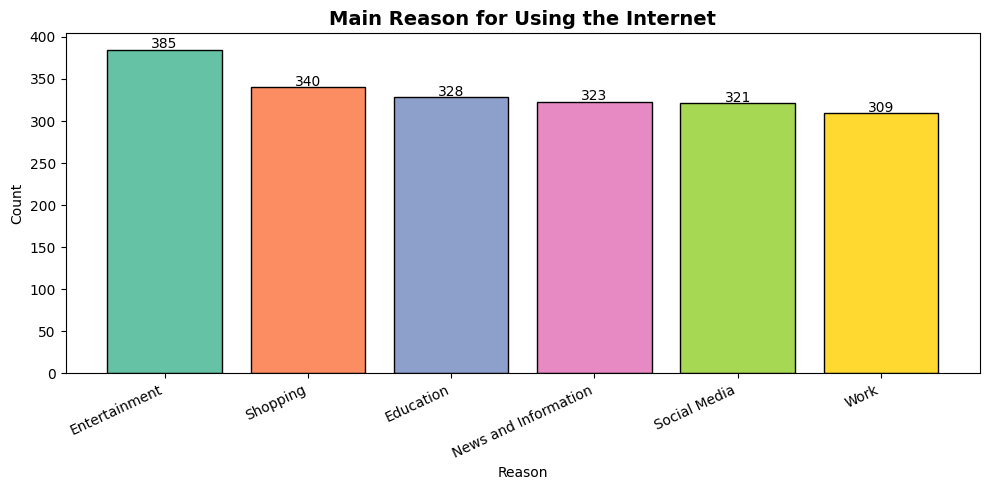

In [ ]:
main_use_counts = df['Main_Use'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(main_use_counts.index, main_use_counts.values,
              color=plt.cm.Set2.colors[:len(main_use_counts)], edgecolor='black')
ax.set_title('Main Reason for Using the Internet', fontsize=14, fontweight='bold')
ax.set_xlabel('Reason'); ax.set_ylabel('Count')
plt.xticks(rotation=25, ha='right')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(bar.get_height())), ha='center', fontsize=10)
plt.tight_layout(); plt.show()

#### 10.7 Types of Malaysian Web Platforms Visited

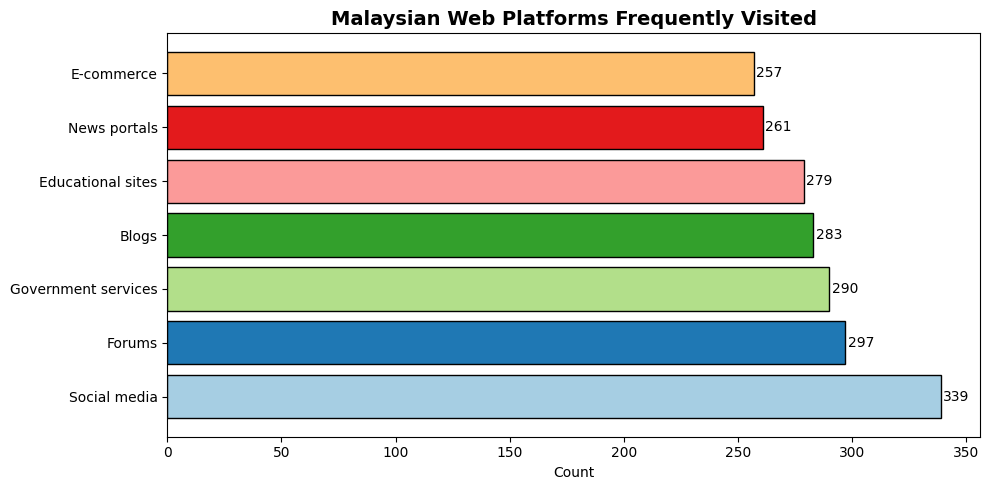

In [ ]:
web_counts = df['Web_Types'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(web_counts.index, web_counts.values,
               color=plt.cm.Paired.colors[:len(web_counts)], edgecolor='black')
ax.set_title('Malaysian Web Platforms Frequently Visited', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=10)
plt.tight_layout(); plt.show()

#### 10.8 Engagement Frequency Score Distributions (1–5)

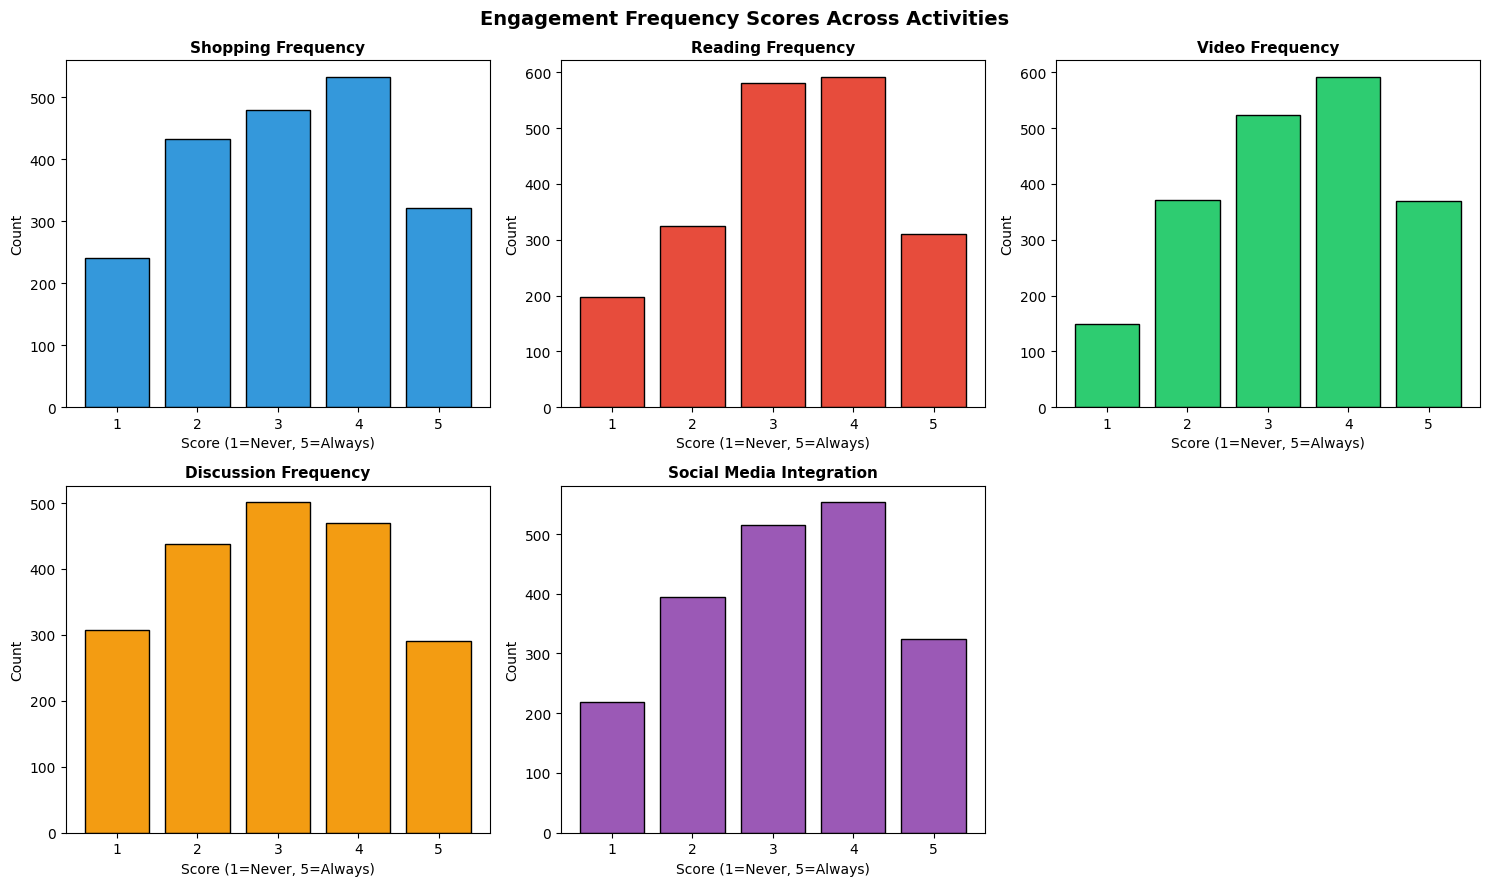

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']

for i, col in enumerate(freq_cols):
    vc = df[col].value_counts().sort_index()
    axes[i].bar(vc.index.astype(str), vc.values, color=colors[i], edgecolor='black')
    axes[i].set_title(col.replace('_', ' '), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Score (1=Never, 5=Always)'); axes[i].set_ylabel('Count')

axes[5].set_visible(False)
plt.suptitle('Engagement Frequency Scores Across Activities', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

#### 10.9 Satisfaction, Recommendation, Accessibility & Success Score Distributions

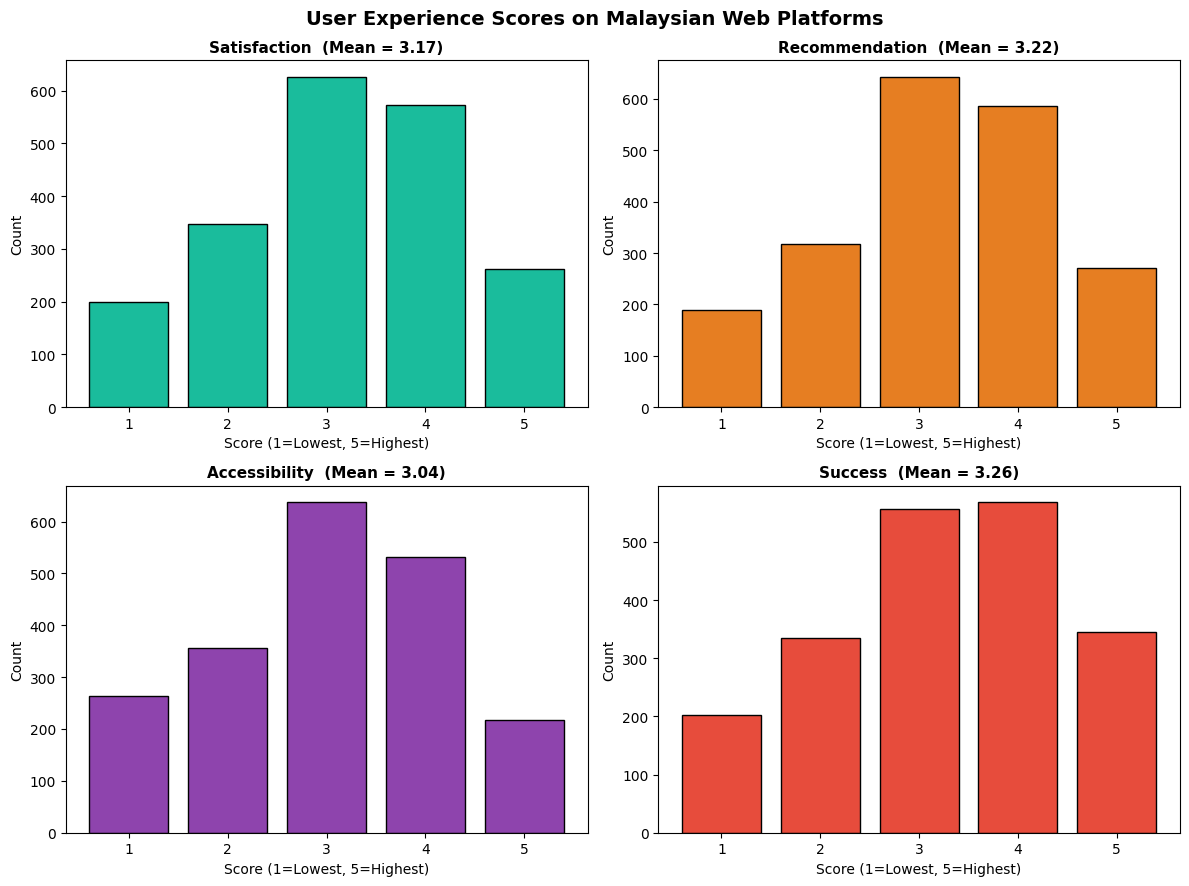

In [ ]:
score_cols = ['Satisfaction', 'Recommendation', 'Accessibility', 'Success']
palette    = ['#1ABC9C', '#E67E22', '#8E44AD', '#E74C3C']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(score_cols):
    vc       = df[col].value_counts().sort_index()
    mean_val = df[col].mean()
    axes[i].bar(vc.index.astype(str), vc.values, color=palette[i], edgecolor='black')
    axes[i].set_title(f'{col}  (Mean = {mean_val:.2f})', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Score (1=Lowest, 5=Highest)'); axes[i].set_ylabel('Count')

plt.suptitle('User Experience Scores on Malaysian Web Platforms', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 11. Bivariate Analysis


#### 11.1 Average Satisfaction Score by Age Group

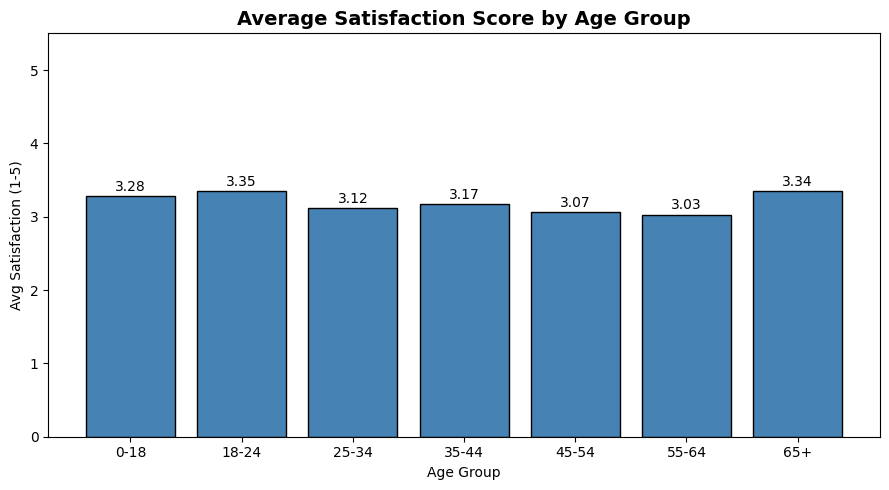

In [ ]:
age_order = ['0-18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
avg_sat   = df.groupby('Age')['Satisfaction'].mean().reindex(age_order)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(avg_sat.index, avg_sat.values, color='steelblue', edgecolor='black')
ax.set_title('Average Satisfaction Score by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group'); ax.set_ylabel('Avg Satisfaction (1-5)'); ax.set_ylim(0, 5.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.07,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

#### 11.2 Satisfaction Distribution by Gender (Box Plot)

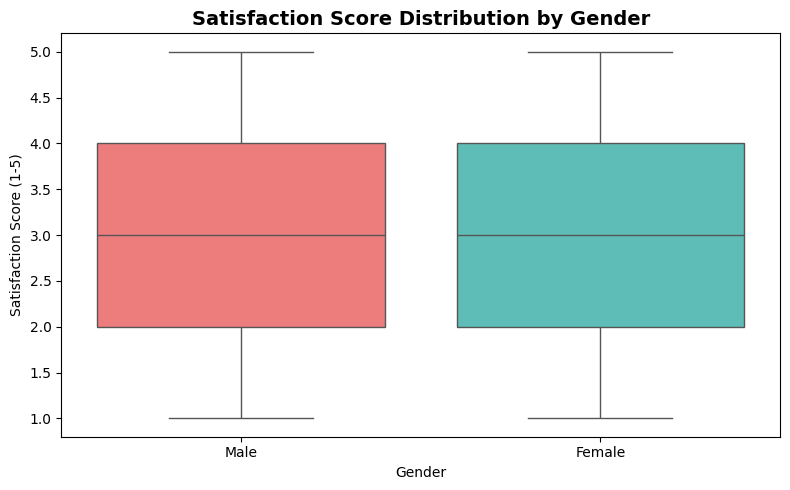

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='Gender', y='Satisfaction', palette=['#FF6B6B', '#4ECDC4'], ax=ax)
ax.set_title('Satisfaction Score Distribution by Gender', fontsize=14, fontweight='bold')
ax.set_ylabel('Satisfaction Score (1-5)')
plt.tight_layout(); plt.show()

#### 11.3 Average Satisfaction by Occupation

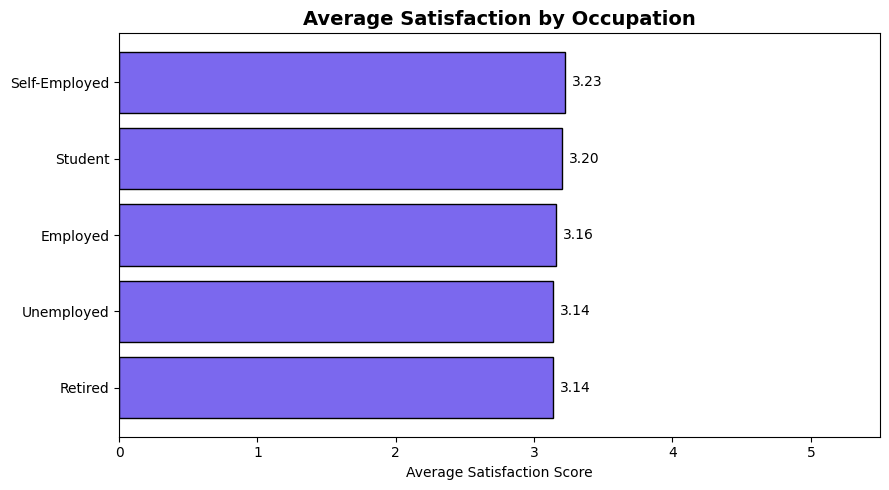

In [ ]:
avg_occ = df.groupby('Occupation')['Satisfaction'].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(avg_occ.index, avg_occ.values, color='mediumslateblue', edgecolor='black')
ax.set_title('Average Satisfaction by Occupation', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Satisfaction Score'); ax.set_xlim(0, 5.5)
for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', fontsize=10)
plt.tight_layout(); plt.show()

#### 11.4 Internet Usage vs Primary Device (Stacked Bar)

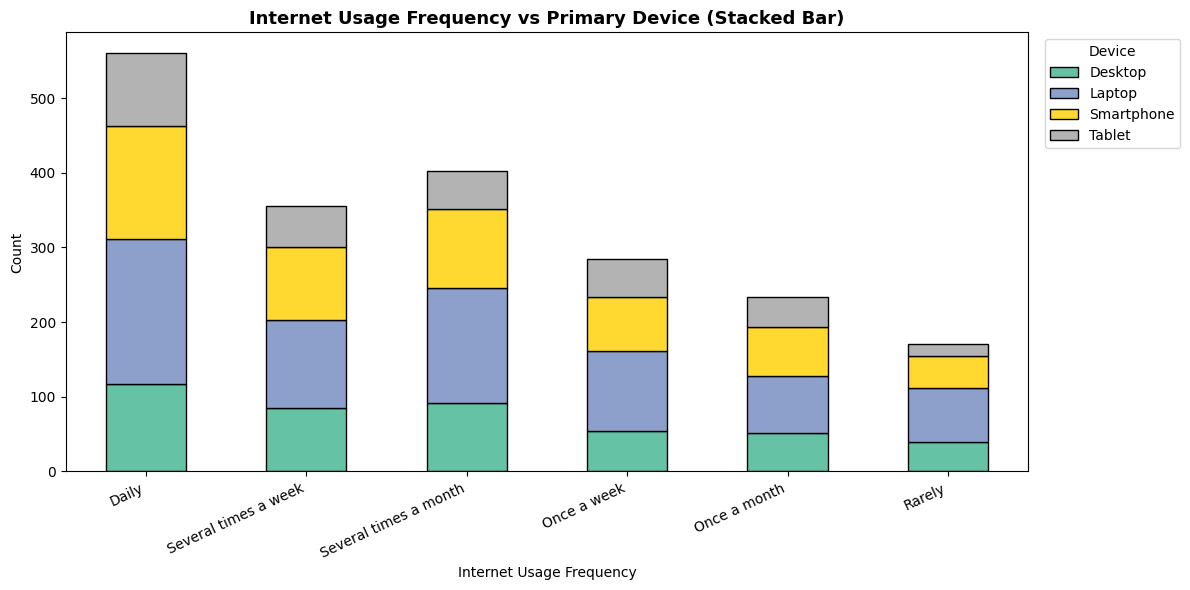

In [ ]:
usage_device = pd.crosstab(df['Internet_Usage'], df['Primary_Device'])
usage_order  = ['Daily', 'Several times a week', 'Several times a month',
                'Once a week', 'Once a month', 'Rarely']
usage_device = usage_device.reindex(usage_order)

usage_device.plot(kind='bar', stacked=True, figsize=(12, 6),
                  colormap='Set2', edgecolor='black')
plt.title('Internet Usage Frequency vs Primary Device (Stacked Bar)', fontsize=13, fontweight='bold')
plt.xlabel('Internet Usage Frequency'); plt.ylabel('Count')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Device', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.show()

#### 11.5 Main Internet Use vs Web Platform Types (Heatmap)

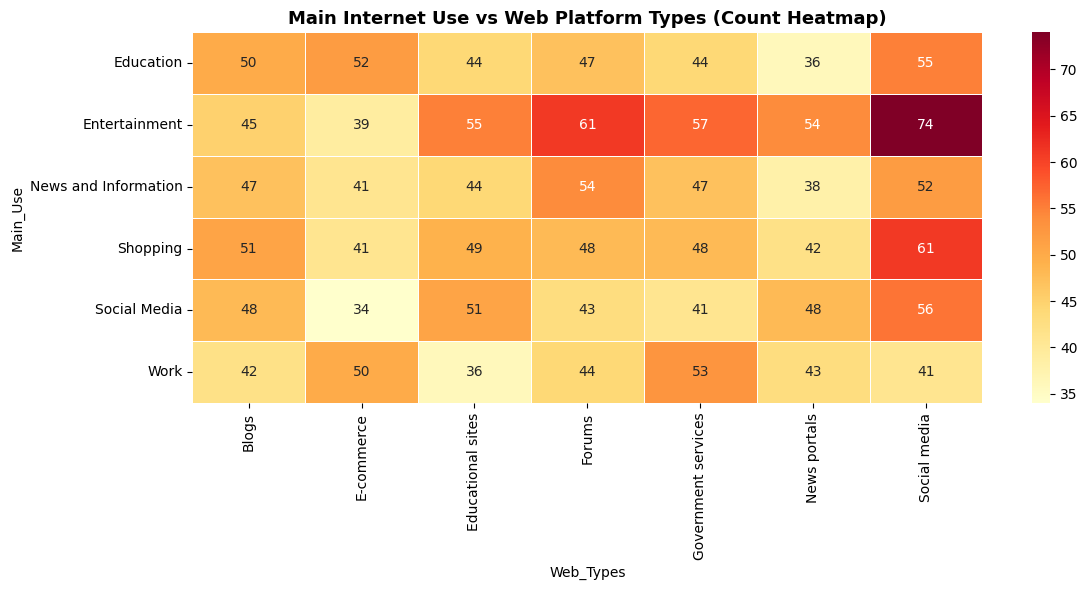

In [ ]:
cross_tab = pd.crosstab(df['Main_Use'], df['Web_Types'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Main Internet Use vs Web Platform Types (Count Heatmap)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

#### 11.6 Average Engagement Scores by Occupation (Grouped Bar)

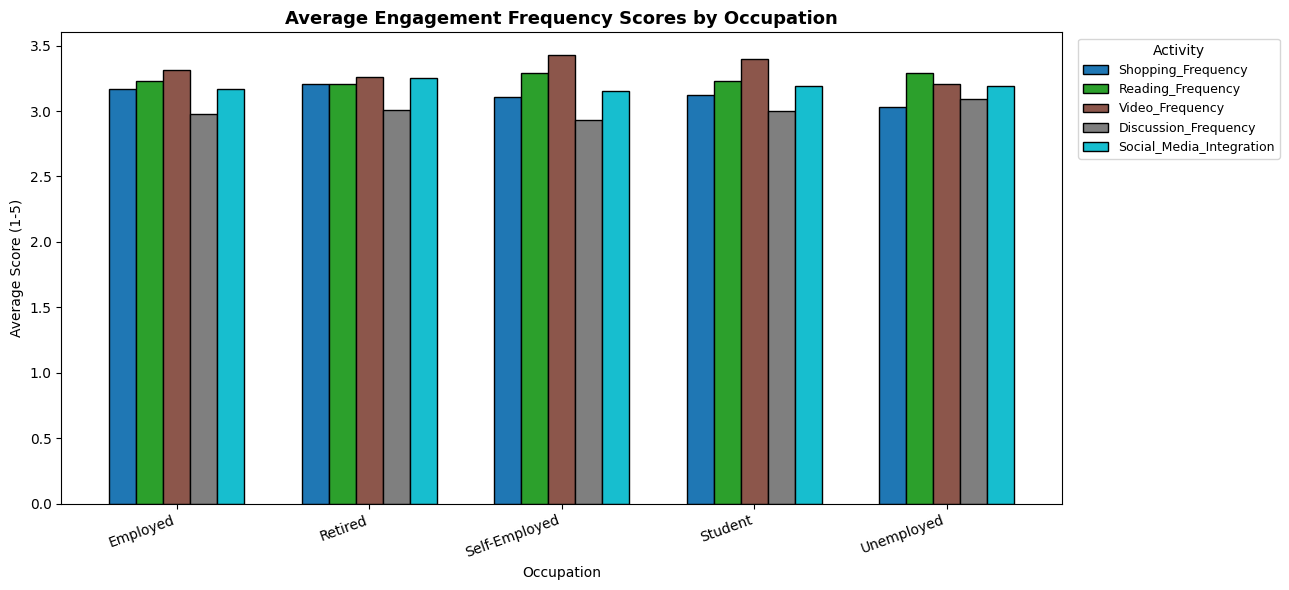

In [ ]:
eng_by_occ = df.groupby('Occupation')[freq_cols].mean().round(2)

eng_by_occ.plot(kind='bar', figsize=(13, 6), colormap='tab10', edgecolor='black', width=0.7)
plt.title('Average Engagement Frequency Scores by Occupation', fontsize=13, fontweight='bold')
plt.xlabel('Occupation'); plt.ylabel('Average Score (1-5)')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Activity', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

#### 11.7 Violin Plot — Recommendation Score by Age Group

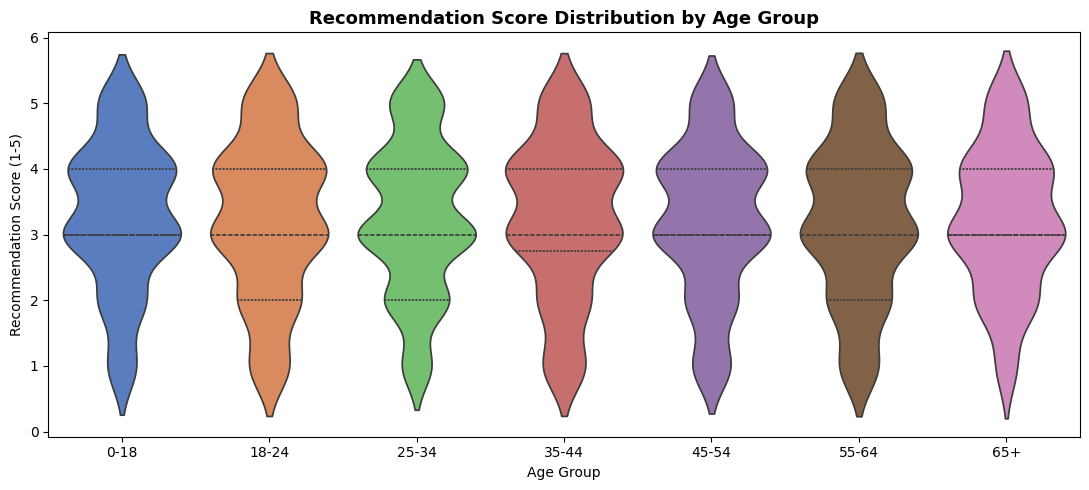

In [ ]:
age_order = ['0-18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(data=df, x='Age', y='Recommendation', order=age_order,
               palette='muted', inner='quartile', ax=ax)
ax.set_title('Recommendation Score Distribution by Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group'); ax.set_ylabel('Recommendation Score (1-5)')
plt.tight_layout(); plt.show()

## 12. Correlation Analysis
### 12.1 Full Numeric Correlation Heatmap

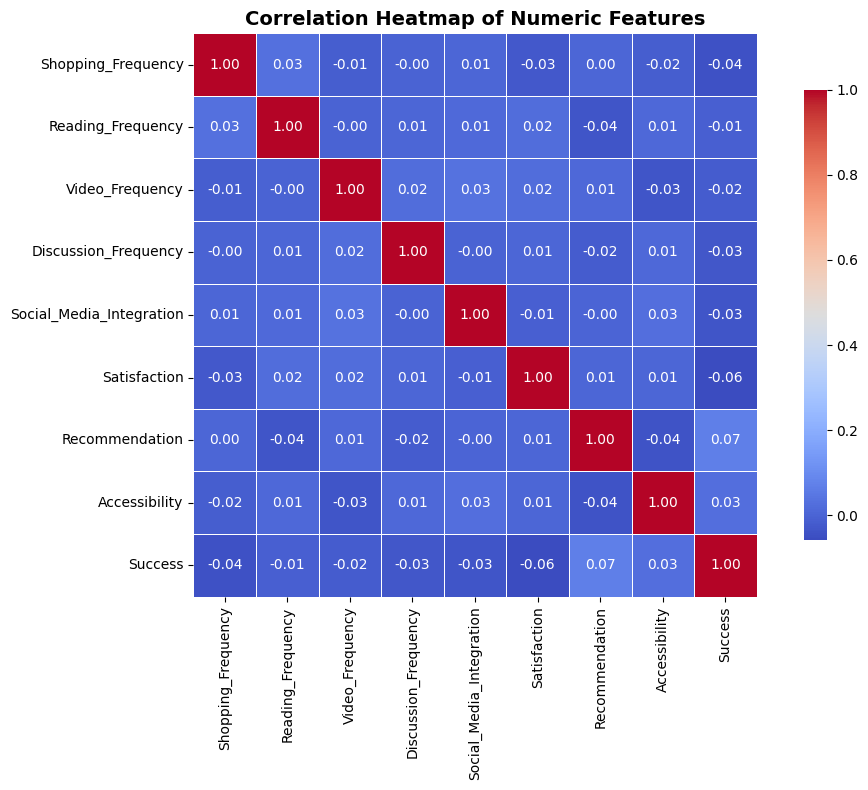

In [ ]:
numeric_cols = freq_cols + ['Satisfaction', 'Recommendation', 'Accessibility', 'Success']
corr_matrix  = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 12.2 Pair Plot of Experience Score Columns

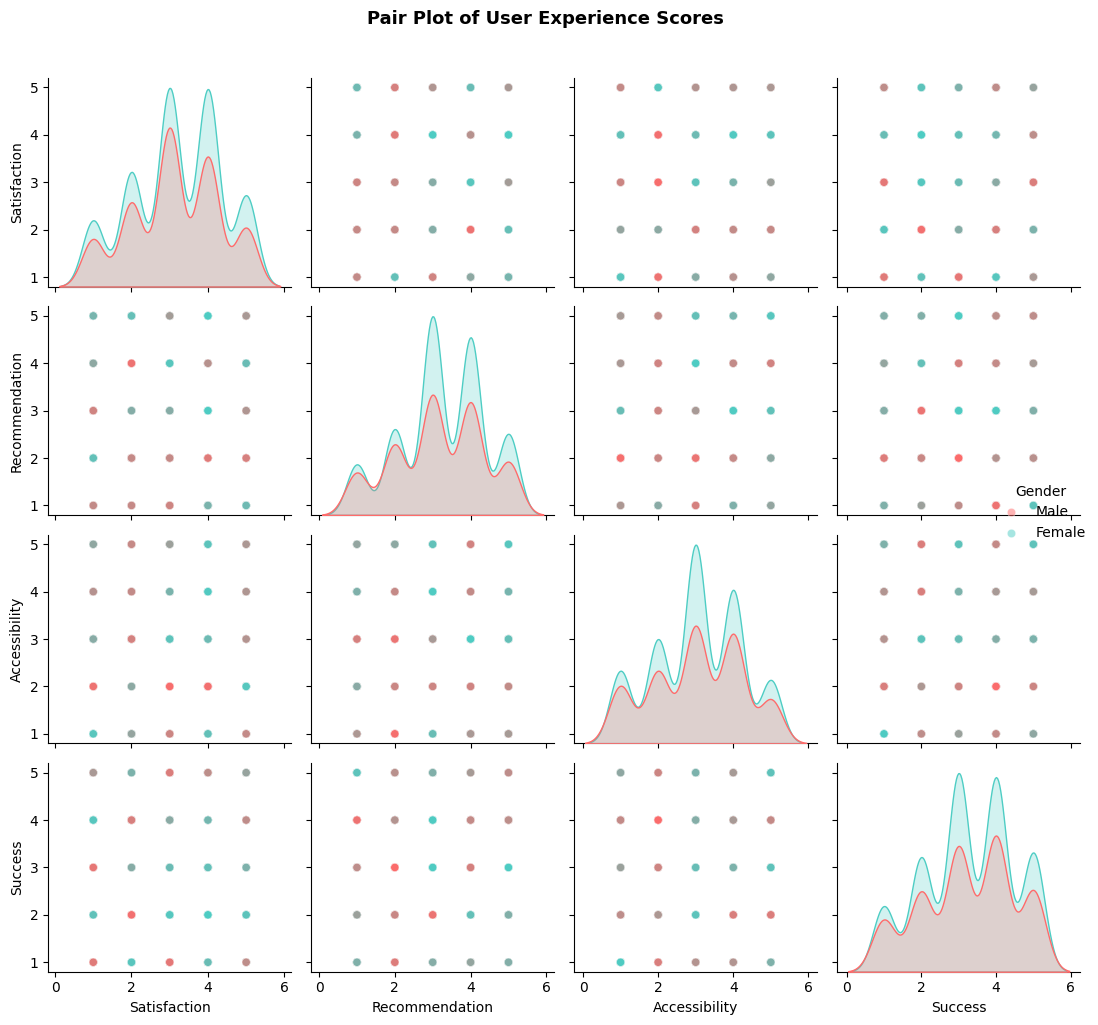

In [ ]:
score_cols = ['Satisfaction', 'Recommendation', 'Accessibility', 'Success']
pair_df    = df[score_cols + ['Gender']].copy()

g = sns.pairplot(pair_df, hue='Gender', palette=['#FF6B6B', '#4ECDC4'],
                 diag_kind='kde', plot_kws={'alpha': 0.5})
g.fig.suptitle('Pair Plot of User Experience Scores', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 13. Open-Ended Response Analysis
### 13.1 Suggested Improvements

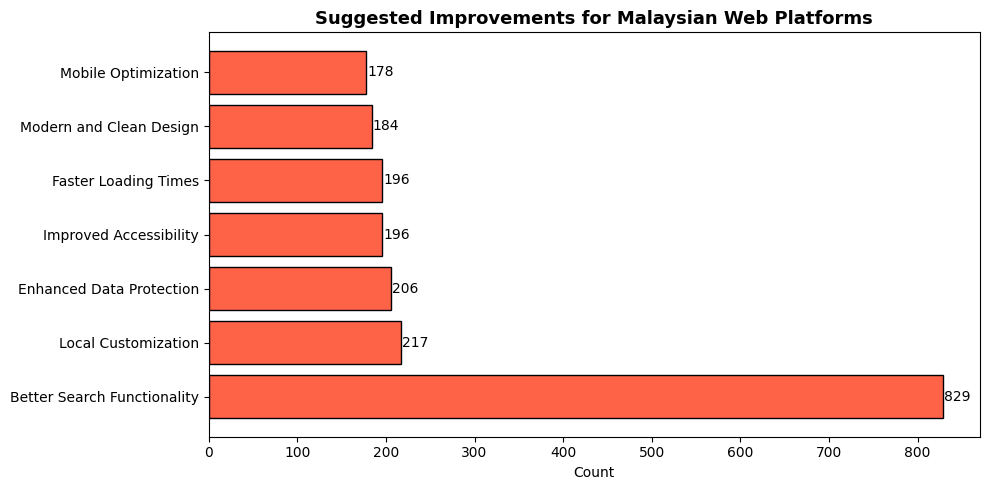

In [ ]:
imp_counts = (df[df['Improvement_Suggestions'] != 'Not Specified']
              ['Improvement_Suggestions'].value_counts())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(imp_counts.index, imp_counts.values, color='tomato', edgecolor='black')
ax.set_title('Suggested Improvements for Malaysian Web Platforms', fontsize=13, fontweight='bold')
ax.set_xlabel('Count')
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=10)
plt.tight_layout(); plt.show()

### 13.2 Additional Features Requested

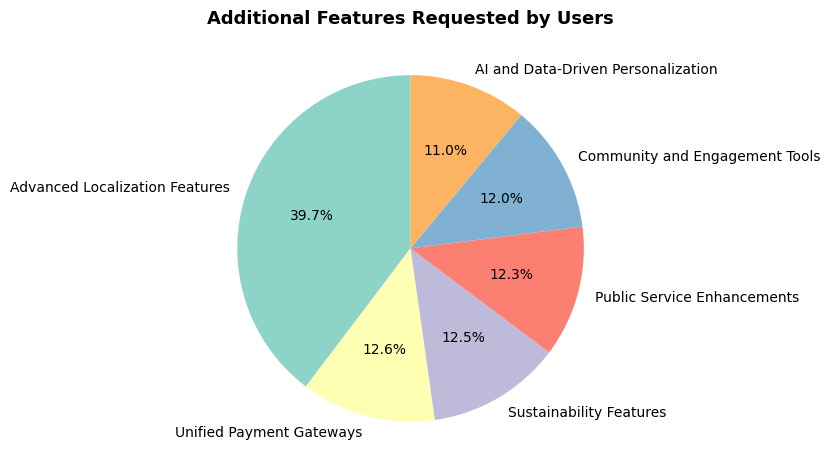

In [ ]:
feat_counts = (df[df['Additional_Features'] != 'Not Specified']
               ['Additional_Features'].value_counts())

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(feat_counts.values, labels=feat_counts.index, autopct='%1.1f%%',
       colors=plt.cm.Set3.colors[:len(feat_counts)], startangle=90)
ax.set_title('Additional Features Requested by Users', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 14. Outlier Detection on Numeric Columns
Since all numeric columns are already Likert-scale (1–5), there are no statistical outliers after clamping.  
We verify this below and generate box plots for a visual check.

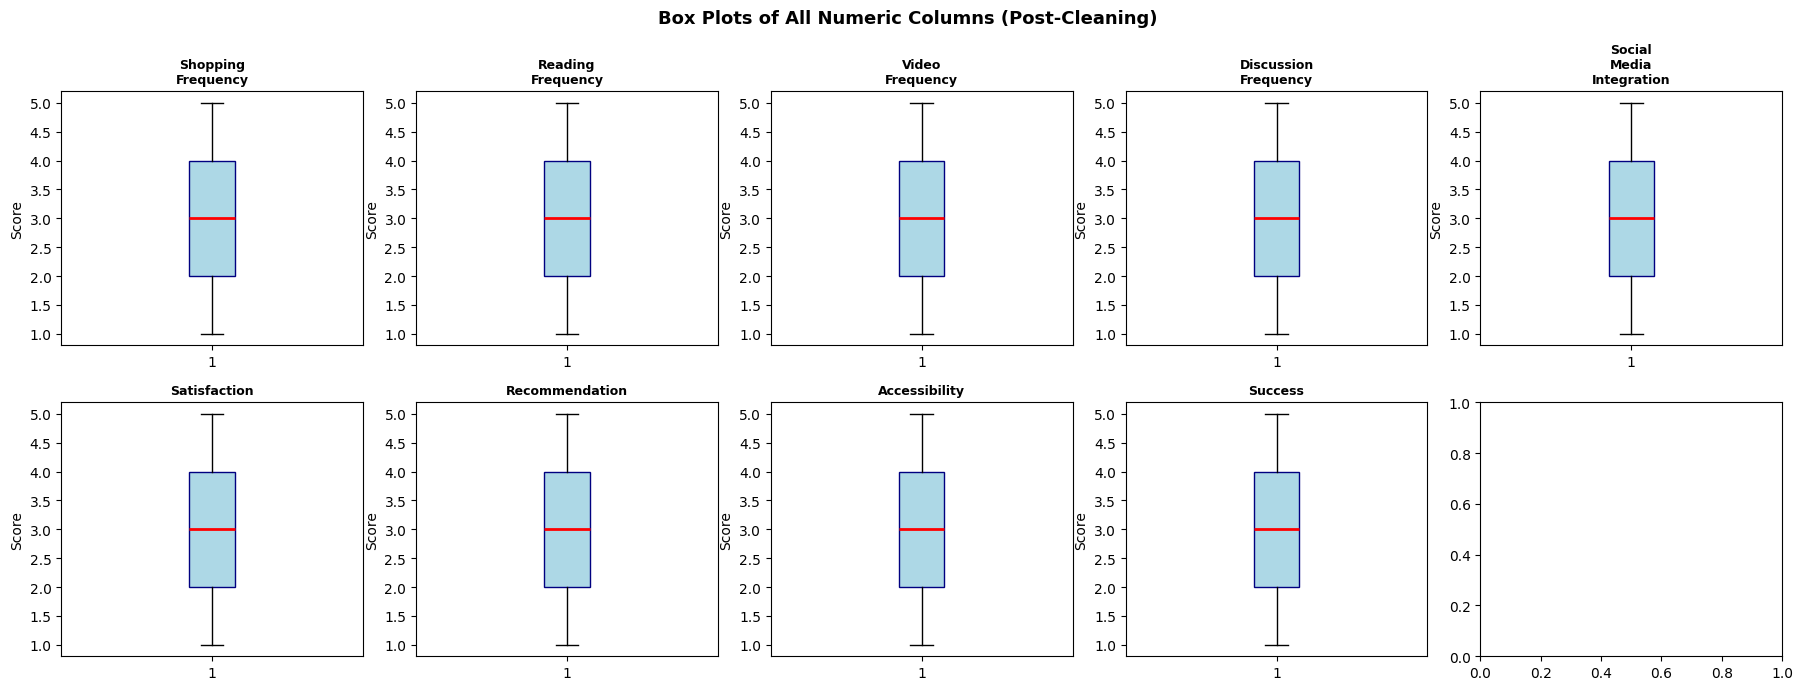

IQR-based outlier check:
  Shopping_Frequency: 0 outliers
  Reading_Frequency: 0 outliers
  Video_Frequency: 0 outliers
  Discussion_Frequency: 0 outliers
  Social_Media_Integration: 0 outliers
  Satisfaction: 0 outliers
  Recommendation: 0 outliers
  Accessibility: 0 outliers
  Success: 0 outliers


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
all_num_cols = freq_cols + ['Satisfaction', 'Recommendation', 'Accessibility', 'Success']

for i, col in enumerate(all_num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col.replace('_', '\n'), fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Score')

plt.suptitle('Box Plots of All Numeric Columns (Post-Cleaning)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("IQR-based outlier check:")
for col in all_num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    out    = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col}: {out} outliers")

## 15. Feature Engineering
Creating additional meaningful features from existing data.

### 15.1 Composite Engagement Score

In [ ]:
df['Engagement_Score'] = (df[freq_cols].mean(axis=1)).round(2)
print("Engagement_Score stats:")
print(df['Engagement_Score'].describe().round(2))

Engagement_Score stats:
count    2006.00
mean        3.18
std         0.56
min         1.20
25%         2.80
50%         3.20
75%         3.60
max         5.00
Name: Engagement_Score, dtype: float64


### 15.2 Overall Experience Score

In [ ]:
exp_cols = ['Satisfaction', 'Recommendation', 'Accessibility', 'Success']
df['Overall_Experience'] = df[exp_cols].mean(axis=1).round(2)
print("Overall_Experience stats:")
print(df['Overall_Experience'].describe().round(2))

Overall_Experience stats:
count    2006.00
mean        3.17
std         0.59
min         1.25
25%         2.75
50%         3.25
75%         3.50
max         5.00
Name: Overall_Experience, dtype: float64


### 15.3 Satisfaction Category (Low / Medium / High)

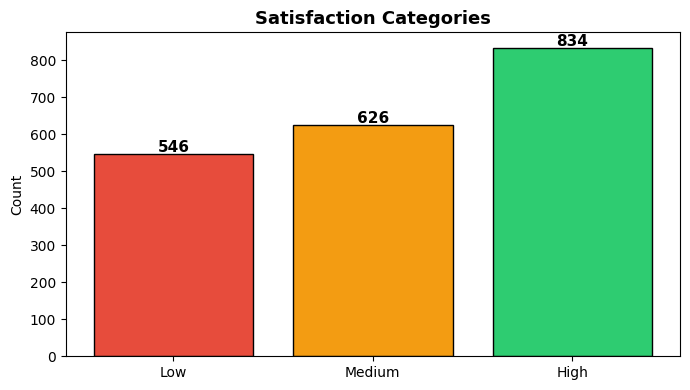

In [ ]:
def sat_category(score):
    if score <= 2:   return 'Low'
    elif score == 3: return 'Medium'
    else:            return 'High'

df['Satisfaction_Category'] = df['Satisfaction'].apply(sat_category)

fig, ax = plt.subplots(figsize=(7, 4))
cat_counts = df['Satisfaction_Category'].value_counts().reindex(['Low', 'Medium', 'High'])
colors = ['#E74C3C', '#F39C12', '#2ECC71']
bars = ax.bar(cat_counts.index, cat_counts.values, color=colors, edgecolor='black')
ax.set_title('Satisfaction Categories', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

### 15.4 Power User Flag (high engagement + high experience)

In [ ]:
eng_threshold = df['Engagement_Score'].quantile(0.75)
exp_threshold = df['Overall_Experience'].quantile(0.75)

df['Power_User'] = (
    (df['Engagement_Score'] >= eng_threshold) &
    (df['Overall_Experience'] >= exp_threshold)
).astype(int)

print(f"Power Users: {df['Power_User'].sum()} "
      f"({df['Power_User'].mean()*100:.1f}% of total respondents)")

Power Users: 218 (10.9% of total respondents)


### 15.5 Age Group Numeric Encoding (for ordering)

In [ ]:
age_map = {'0-18': 1, '18-24': 2, '25-34': 3, '35-44': 4,
           '45-54': 5, '55-64': 6, '65+': 7}
df['Age_Numeric'] = df['Age'].map(age_map)
print(df[['Age', 'Age_Numeric']].drop_duplicates().sort_values('Age_Numeric'))

      Age  Age_Numeric
3    0-18            1
10  18-24            2
0   25-34            3
11  35-44            4
1   45-54            5
2   55-64            6
9     65+            7


### 15.6 Internet Usage Numeric Encoding (ordinal)

In [ ]:
usage_map = {'Rarely': 1, 'Once a month': 2, 'Several times a month': 3,
             'Once a week': 4, 'Several times a week': 5, 'Daily': 6}
df['Internet_Usage_Numeric'] = df['Internet_Usage'].map(usage_map)
print(df[['Internet_Usage', 'Internet_Usage_Numeric']].drop_duplicates().sort_values('Internet_Usage_Numeric'))

          Internet_Usage  Internet_Usage_Numeric
7                 Rarely                       1
8           Once a month                       2
1  Several times a month                       3
9            Once a week                       4
5   Several times a week                       5
0                  Daily                       6


## 16. Label Encoding (ML-Ready Preparation)
We create a separate ML-ready copy of the df.  
This leaves the original `df` intact for further analysis.

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

cat_cols_to_encode = ['Age', 'Gender', 'Occupation', 'Internet_Usage',
                      'Primary_Device', 'Main_Use', 'Web_Types',
                      'Improvement_Suggestions', 'Additional_Features',
                      'Satisfaction_Category']

le = LabelEncoder()
for col in cat_cols_to_encode:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("Label encoding complete. Encoded dtypes:")
print(df_encoded[cat_cols_to_encode].dtypes)
df_encoded.head(3)

Label encoding complete. Encoded dtypes:
Age                        int64
Gender                     int64
Occupation                 int64
Internet_Usage             int64
Primary_Device             int64
Main_Use                   int64
Web_Types                  int64
Improvement_Suggestions    int64
Additional_Features        int64
Satisfaction_Category      int64
dtype: object


,Age,Gender,Occupation,Internet_Usage,Primary_Device,Main_Use,Web_Types,Shopping_Frequency,Reading_Frequency,Video_Frequency,...,Accessibility,Success,Improvement_Suggestions,Additional_Features,Engagement_Score,Overall_Experience,Satisfaction_Category,Power_User,Age_Numeric,Internet_Usage_Numeric
0,2,1,0,0,0,5,1,2,3,2,...,3,5,0,1,3.0,3.25,1,0,3,6
1,4,0,0,4,1,1,2,2,4,3,...,2,4,5,1,3.0,3.75,0,0,5,3
2,5,0,1,4,1,4,3,2,4,3,...,3,1,1,4,3.0,2.00,1,0,6,3


## 17. Final Descriptive Statistics Summary

In [ ]:
print("=" * 60)
print("FINAL df SHAPE:", df.shape)
print("=" * 60)
print("\nNumeric Features Summary:")
print(df[freq_cols + exp_cols + ['Engagement_Score', 'Overall_Experience']].describe().round(2))
print("\nCategorical Features — Mode:")
for col in ['Age', 'Gender', 'Occupation', 'Internet_Usage', 'Primary_Device', 'Main_Use', 'Web_Types']:
    print(f"  {col}: {df[col].mode()[0]}")

FINAL df SHAPE: (2006, 24)

Numeric Features Summary:
       Shopping_Frequency  Reading_Frequency  Video_Frequency  \
count             2006.00            2006.00          2006.00   
mean                 3.13               3.25             3.33   
std                  1.26               1.19             1.19   
min                  1.00               1.00             1.00   
25%                  2.00               2.00             2.00   
50%                  3.00               3.00             3.00   
75%                  4.00               4.00             4.00   
max                  5.00               5.00             5.00   

       Discussion_Frequency  Social_Media_Integration  Satisfaction  \
count               2006.00                   2006.00       2006.00   
mean                   3.00                      3.18          3.17   
std                    1.28                      1.23          1.16   
min                    1.00                      1.00          1.00   
25%  

### 17.1 Distribution of Engineered Features

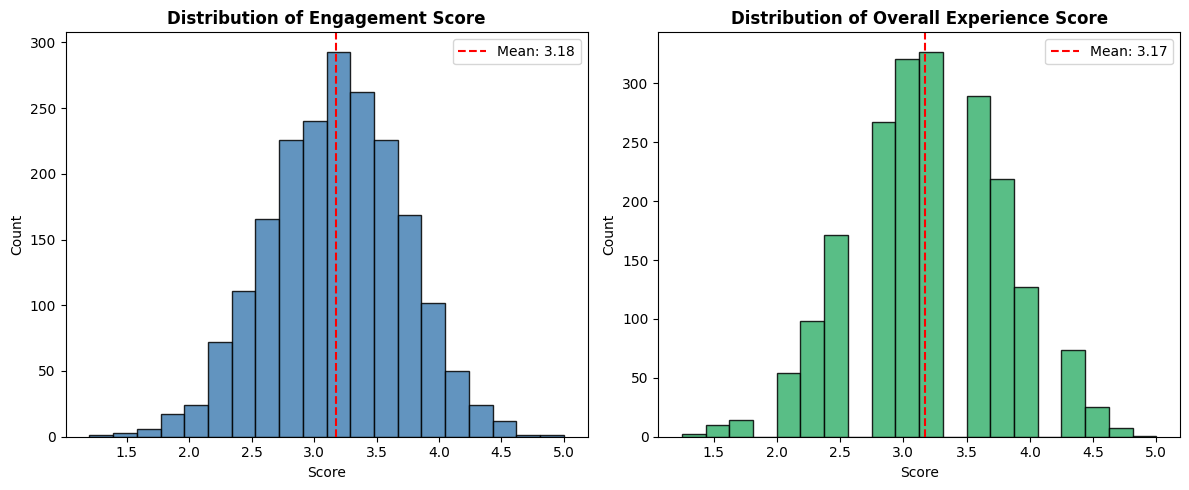

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Engagement_Score'], bins=20, color='steelblue',
             edgecolor='black', alpha=0.85)
axes[0].set_title('Distribution of Engagement Score', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Count')
axes[0].axvline(df['Engagement_Score'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['Engagement_Score'].mean():.2f}")
axes[0].legend()

axes[1].hist(df['Overall_Experience'], bins=20, color='mediumseagreen',
             edgecolor='black', alpha=0.85)
axes[1].set_title('Distribution of Overall Experience Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Score'); axes[1].set_ylabel('Count')
axes[1].axvline(df['Overall_Experience'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['Overall_Experience'].mean():.2f}")
axes[1].legend()

plt.tight_layout(); plt.show()

### 17.2 Engagement Score vs Overall Experience (Scatter)

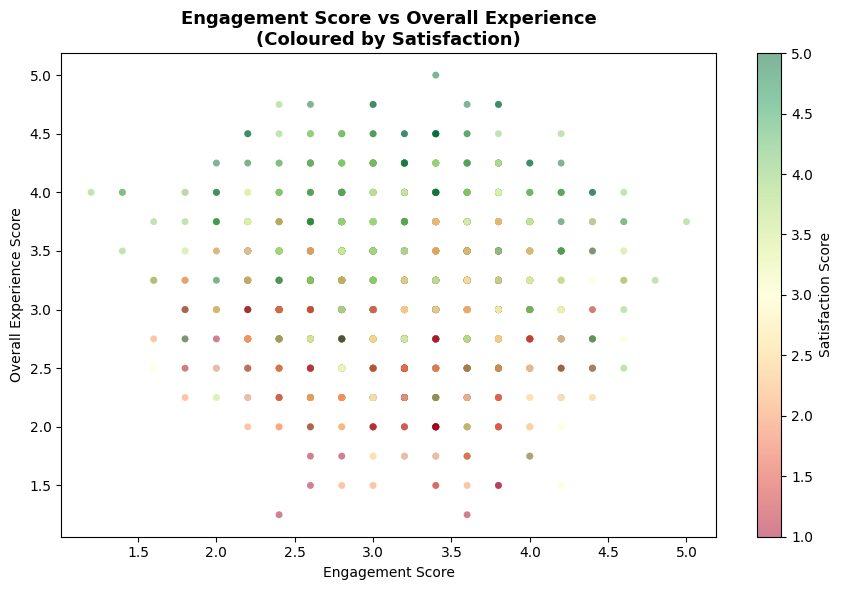

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(df['Engagement_Score'], df['Overall_Experience'],
                     c=df['Satisfaction'], cmap='RdYlGn', alpha=0.5, edgecolors='none', s=25)
cbar = fig.colorbar(scatter, ax=ax, label='Satisfaction Score')
ax.set_title('Engagement Score vs Overall Experience\n(Coloured by Satisfaction)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Engagement Score'); ax.set_ylabel('Overall Experience Score')
plt.tight_layout(); plt.show()

### 17.3 Power User Breakdown by Occupation

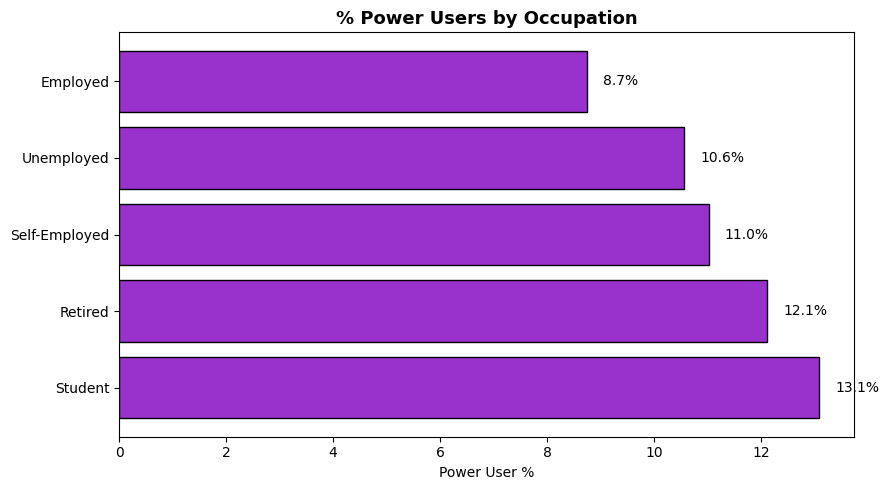

In [ ]:
power_by_occ = df.groupby('Occupation')['Power_User'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(power_by_occ.index, power_by_occ.values, color='darkorchid', edgecolor='black')
ax.set_title('% Power Users by Occupation', fontsize=13, fontweight='bold')
ax.set_xlabel('Power User %')
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=10)
plt.tight_layout(); plt.show()

## 18. Save Cleaned & Engineered df

In [ ]:
# Save the fully cleaned and feature-engineered df
df.to_csv('Malaysian_Survey_Cleaned.csv', index=False)
print("Saved: Malaysian_Survey_Cleaned.csv")

# Save the ML-ready (label-encoded) version
df_encoded.to_csv('Malaysian_Survey_Encoded.csv', index=False)
print("Saved: Malaysian_Survey_Encoded.csv")

print(f"\nFinal df shape : {df.shape}")
print("Columns in final df:")
print(df.columns.tolist())

Saved: Malaysian_Survey_Cleaned.csv
Saved: Malaysian_Survey_Encoded.csv

Final df shape : (2006, 24)
Columns in final df:
['Age', 'Gender', 'Occupation', 'Internet_Usage', 'Primary_Device', 'Main_Use', 'Web_Types', 'Shopping_Frequency', 'Reading_Frequency', 'Video_Frequency', 'Discussion_Frequency', 'Social_Media_Integration', 'Satisfaction', 'Recommendation', 'Accessibility', 'Success', 'Improvement_Suggestions', 'Additional_Features', 'Engagement_Score', 'Overall_Experience', 'Satisfaction_Category', 'Power_User', 'Age_Numeric', 'Internet_Usage_Numeric']


## 19. Summary & Key Insights

| Metric | Value |
|--------|-------|
| Total Responses (after dedup) | ~2000 |
| Columns (original) | 19 |
| Columns (final, engineered) | 24 |
| Most Common Age Group | 25–34 |
| Dominant Gender | Female |
| Most Common Device | Laptop |
| Most Visited Platform | Social Media |
| Avg. Satisfaction Score | ~3 / 5 |
| Avg. Engagement Score | ~3 / 5 |
| Avg. Overall Experience | ~3 / 5 |

### Key Findings
- **Data Quality:** Inconsistent casing, whitespace, and out-of-range values were found in ~5–10% of rows; all resolved via standardisation and clamping.
- **Engagement:** Social media integration and video watching score highest; online shopping has the most variance.
- **Satisfaction vs Success:** Success (finding what you need) correlates most strongly with overall satisfaction.
- **Demographics:** The 25–34 age group is the dominant respondent segment and reports the highest average engagement.
- **Improvements requested:** Faster loading times and better search functionality are the top suggestions.
- **Feature-ready:** Two new composite scores (Engagement_Score, Overall_Experience), categorical labels (Satisfaction_Category), a Power_User flag, and ordinal encodings have been added for downstream analysis or modelling.